# ATS Machine Learning
## Prediksi Kecelakaan Kerja - PT Besli Manufacturing

Nama: Yosua Dirgana Pratama  
NIM: 4222301009

PT Besli Manufacturing mengalami beberapa insiden kecelakaan kerja. Oleh karena itu, diperlukan sistem prediksi berbasis Machine Learning untuk mengidentifikasi karyawan yang berisiko mengalami kecelakaan kerja.

Dengan memanfaatkan data historis seperti usia, pengalaman kerja, dan faktor lainnya, model diharapkan dapat membantu perusahaan dalam melakukan pencegahan.

Tujuan dari penelitian ini adalah:
1. Membangun model Machine Learning untuk memprediksi risiko kecelakaan kerja
2. Membantu perusahaan dalam pengambilan keputusan keselamatan kerja

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset_kecelakaan.csv")
df.head()

,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0


Persentase Kelas Kecelakaan:
Kecelakaan
0    72.0
1    28.0
Name: proportion, dtype: float64


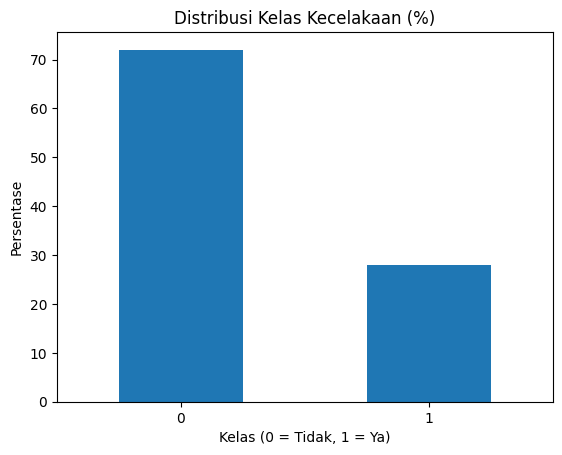

In [3]:
# =========================
# CLASS IMBALANCE CHECK
# =========================

print("Persentase Kelas Kecelakaan:")

class_distribution = df['Kecelakaan'].value_counts(normalize=True) * 100
print(class_distribution)

# (Opsional) Visualisasi distribusi kelas
import matplotlib.pyplot as plt

plt.figure()
class_distribution.plot(kind='bar')
plt.title("Distribusi Kelas Kecelakaan (%)")
plt.xlabel("Kelas (0 = Tidak, 1 = Ya)")
plt.ylabel("Persentase")
plt.xticks(rotation=0)
plt.show()

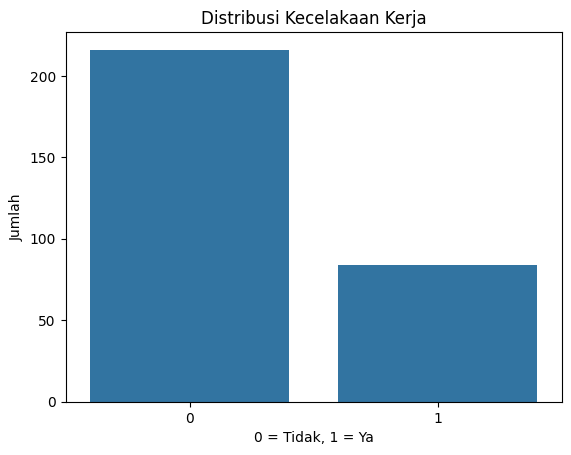

In [4]:
plt.figure()
sns.countplot(x='Kecelakaan', data=df)
plt.title("Distribusi Kecelakaan Kerja")
plt.xlabel("0 = Tidak, 1 = Ya")
plt.ylabel("Jumlah")
plt.show()

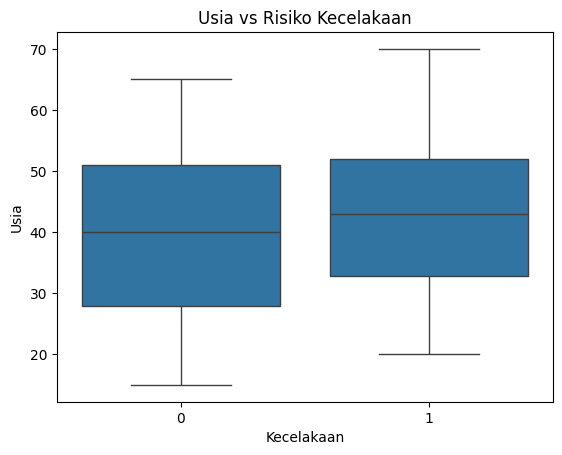

In [5]:
plt.figure()
sns.boxplot(x='Kecelakaan', y='Usia', data=df)
plt.title("Usia vs Risiko Kecelakaan")
plt.show()

In [6]:
data = pd.get_dummies(df, drop_first=True)

# hapus ID (tidak penting)
data = data.drop('ID', axis=1)

# fitur tambahan
data['Rasio_Pengalaman'] = df['Usia'] / (df['Pengalaman_Tahun'] + 1)

data.head()

,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan,Pelatihan_K3_Ya,Shift_Pagi,Shift_Siang,Jabatan_Operator,Jabatan_Supervisor,Lokasi_Produksi,Lokasi_Quality_Control,Rasio_Pengalaman
0,58,47,10,0,True,True,False,False,True,False,False,5.272727
1,48,44,17,0,False,False,True,False,True,False,False,2.666667
2,34,40,22,0,True,True,False,False,False,False,False,1.478261
3,27,37,26,0,False,False,False,False,False,False,False,1.000000
4,40,42,25,0,False,True,False,False,True,False,False,1.538462


In [7]:
X = data.drop('Kecelakaan', axis=1)
y = data['Kecelakaan']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# SCALING CHECK


In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

K = 1, Accuracy = 0.5667
K = 2, Accuracy = 0.6667
K = 3, Accuracy = 0.5667
K = 4, Accuracy = 0.6167
K = 5, Accuracy = 0.5667
K = 6, Accuracy = 0.6833
K = 7, Accuracy = 0.6833
K = 8, Accuracy = 0.6833
K = 9, Accuracy = 0.6667
K = 10, Accuracy = 0.6833


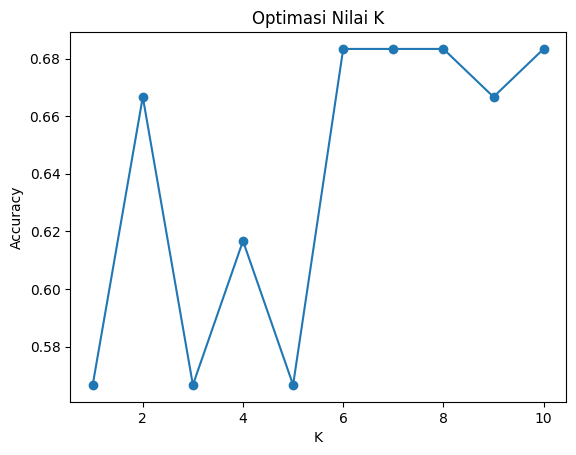

In [17]:
k_values = range(1, 11)
accuracy_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    accuracy_list.append(acc)
    print(f"K = {k}, Accuracy = {acc:.4f}")

plt.figure()
plt.plot(k_values, accuracy_list, marker='o')
plt.title("Optimasi Nilai K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()


# MODEL COMPARISON


In [27]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross Validation Score:", cv_scores)
print("Rata-rata CV Score:", cv_scores.mean())

Cross Validation Score: [0.60416667 0.625      0.66666667 0.64583333 0.6875    ]
Rata-rata CV Score: 0.6458333333333333


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[34  8]
 [18  0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        42
           1       0.00      0.00      0.00        18

    accuracy                           0.57        60
   macro avg       0.33      0.40      0.36        60
weighted avg       0.46      0.57      0.51        60



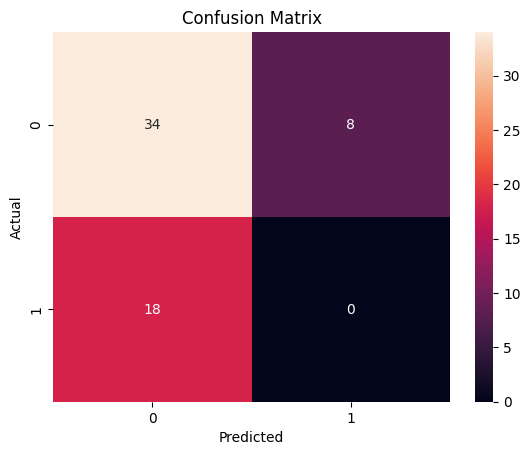

In [12]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

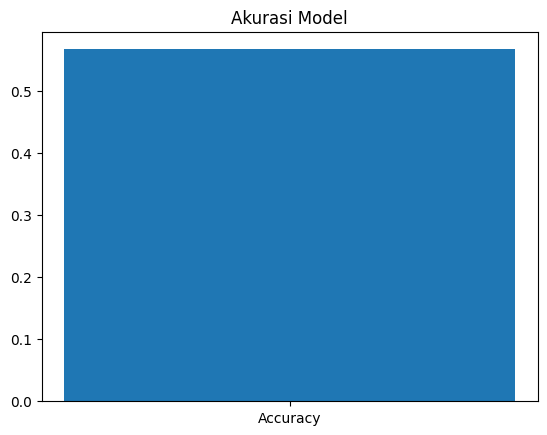

In [13]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)

plt.figure()
plt.bar(['Accuracy'], [acc])
plt.title("Akurasi Model")
plt.show()

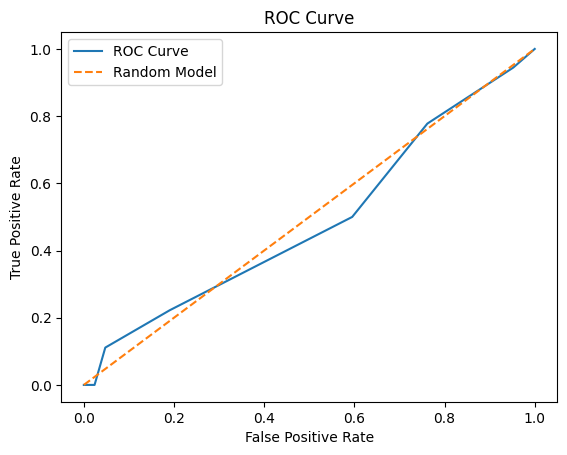

In [21]:
from sklearn.metrics import roc_curve

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Model")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature engineering adalah proses mengubah data mentah menjadi bentuk yang lebih sesuai untuk model Machine Learning.

Pada studi kasus ini, dilakukan:
1. Encoding data kategorikal menggunakan get_dummies agar data dapat diproses oleh model.
2. Penambahan fitur baru yaitu Rasio_Pengalaman = Usia / (Pengalaman + 1) untuk membantu model memahami tingkat pengalaman relatif karyawan.

Feature engineering membantu meningkatkan performa model dalam memprediksi risiko kecelakaan kerja.

Metode K-Nearest Neighbor (KNN) digunakan untuk melakukan klasifikasi berdasarkan kedekatan data.

Model akan mencari sejumlah tetangga terdekat (k) dari data uji, kemudian menentukan kelas berdasarkan mayoritas tetangga tersebut. Pada penelitian ini digunakan nilai k = 5.

Confusion Matrix digunakan untuk mengevaluasi performa model klasifikasi.

- True Positive (TP): Model benar memprediksi karyawan berisiko
- True Negative (TN): Model benar memprediksi karyawan tidak berisiko
- False Positive (FP): Model salah memprediksi berisiko
- False Negative (FN): Model gagal mendeteksi risiko

Metrik evaluasi:
- Accuracy: Persentase prediksi yang benar
- Precision: Ketepatan prediksi risiko
- Recall: Kemampuan model mendeteksi risiko (paling penting)
- F1-score: Kombinasi precision dan recall

Dalam studi kasus ini, recall menjadi fokus utama karena berkaitan dengan keselamatan kerja.

Model Decision Tree berhasil digunakan untuk memprediksi risiko kecelakaan kerja pada karyawan.

Dengan bantuan feature engineering dan evaluasi menggunakan confusion matrix, model mampu memberikan prediksi yang cukup baik.

Sistem ini dapat digunakan sebagai alat bantu untuk meningkatkan keselamatan kerja di PT Besli Manufacturing.

Model KNN berhasil digunakan untuk memprediksi risiko kecelakaan kerja berdasarkan data karyawan.

Dengan bantuan feature engineering dan evaluasi menggunakan confusion matrix serta metrik evaluasi, model mampu memberikan hasil yang cukup baik.

Model ini dapat digunakan sebagai alat bantu dalam pengambilan keputusan untuk meningkatkan keselamatan kerja di PT Besli Manufacturing.